In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl


mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["mathtext.rm"] = "Times New Roman"
mpl.rcParams["axes.unicode_minus"] = False
plt.style.use("tableau-colorblind10")

#mpl.style.use('tableau-colorblind10') 

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [2]:
PKL_PATH  = "parameters_C_ERF_lifetime/ERF_C_lifetime_CO2CH4N2O_1001ensemble_dicts_run2026-02-23.pkl"   

SSPS = ["ssp119", "ssp126", "ssp245", "ssp585"]

SSP_LABELS = {
    "ssp119": "SSP1-1.9",
    "ssp126": "SSP1-2.6",
    "ssp245": "SSP2-4.5",
    "ssp585": "SSP5-8.5",
}
"""
SSP_COLORS = {
    "ssp119": "green",
    "ssp126": "blue",
    "ssp245": "orange",
    "ssp585": "gray",
}
"""

YLABEL = {
    "CO2": r"CO$_2$ concentration (ppm)",
    "CH4": r"CH$_4$ concentration (ppb)",
    "N2O": r"N$_2$O concentration (ppb)",
}


# Grab palette from active style
TABLEAU_COLORS = mpl.rcParams['axes.prop_cycle'].by_key()['color']

# Match exactly IRF/CRF notebook ordering
SSP_COLORS = {
    "ssp119": "#3A923A",          # color-blind friendly green (custom)
    "ssp126": TABLEAU_COLORS[0],  # blue  (#006BA4)
    "ssp245": TABLEAU_COLORS[1],  # orange (#FF800E)
    "ssp585": TABLEAU_COLORS[2],  # gray   (#ABABAB)
}

In [3]:

def plot_fair_concentration_3x1_all_gases(
    pkl_path: str,
    year_min: int = 2000,
    year_max: int = 2300,
    y_start: int = 2000,
    band_q=(5, 95),
    band_alpha: float = 0.2,
):

    with open(pkl_path, "rb") as f:
        payload = pickle.load(f)

    gas_map = {
        "CO2": "co2_all_ensemble_dict",
        "CH4": "ch4_all_ensemble_dict",
        "N2O": "n2o_all_ensemble_dict",
    }

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=True)

    for ax, gas in zip(axes, ["CO2", "CH4", "N2O"]):

        conc_dict = payload[gas_map[gas]]["gas_C"]

        sample_arr = np.asarray(conc_dict["ssp119"])
        n_years = sample_arr.shape[0]
        years = np.arange(y_start, y_start + n_years)
        mask = (years >= year_min) & (years <= year_max)

        qlo, qhi = band_q

        for ssp in SSPS:

            if ssp not in conc_dict:
                continue

            ens = np.asarray(conc_dict[ssp], dtype=float)

            median = np.median(ens, axis=1)
            p_low = np.percentile(ens, qlo, axis=1)
            p_high = np.percentile(ens, qhi, axis=1)

            color = SSP_COLORS[ssp]
            label = SSP_LABELS[ssp]
        
            ax.fill_between(
                years[mask],
                p_low[mask],
                p_high[mask],
                color=color,
                alpha=band_alpha
            )
        

            ax.plot(
                years[mask],
                median[mask],
                color=color,
                linewidth=2.5,
                label=label
            )

        ax.set_ylabel(YLABEL[gas], fontsize=14)

        GAS_TITLE = {
            "CO2": r"CO$_2$", # concentration (FaIR)",
            "CH4": r"CH$_4$", # concentration (FaIR)",
            "N2O": r"N$_2$O" # concentration (FaIR)",
        }
        
        ax.set_title(GAS_TITLE[gas], fontsize=16)
        
        ax.grid(True)
        ax.tick_params(axis='both', labelsize=14)
        
        # ---- Legend customized ----
        if gas == "CO2":
        
            band_patch = Patch(
                facecolor="lightgray",
                edgecolor="none",
                alpha=band_alpha,
                label="FaIR 5-95%"
            )
        
            line_handles = [
                Line2D([0], [0], color=SSP_COLORS[s], lw=2.5, label=SSP_LABELS[s])
                for s in SSPS
            ]
        
            ax.legend(
                handles=[band_patch] + line_handles,
                fontsize=14,
                frameon=True
            )

        ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))

    axes[-1].set_xlabel("Year", fontsize=14)
    axes[-1].set_xlim(year_min, year_max)

    plt.tight_layout()
    plt.show()

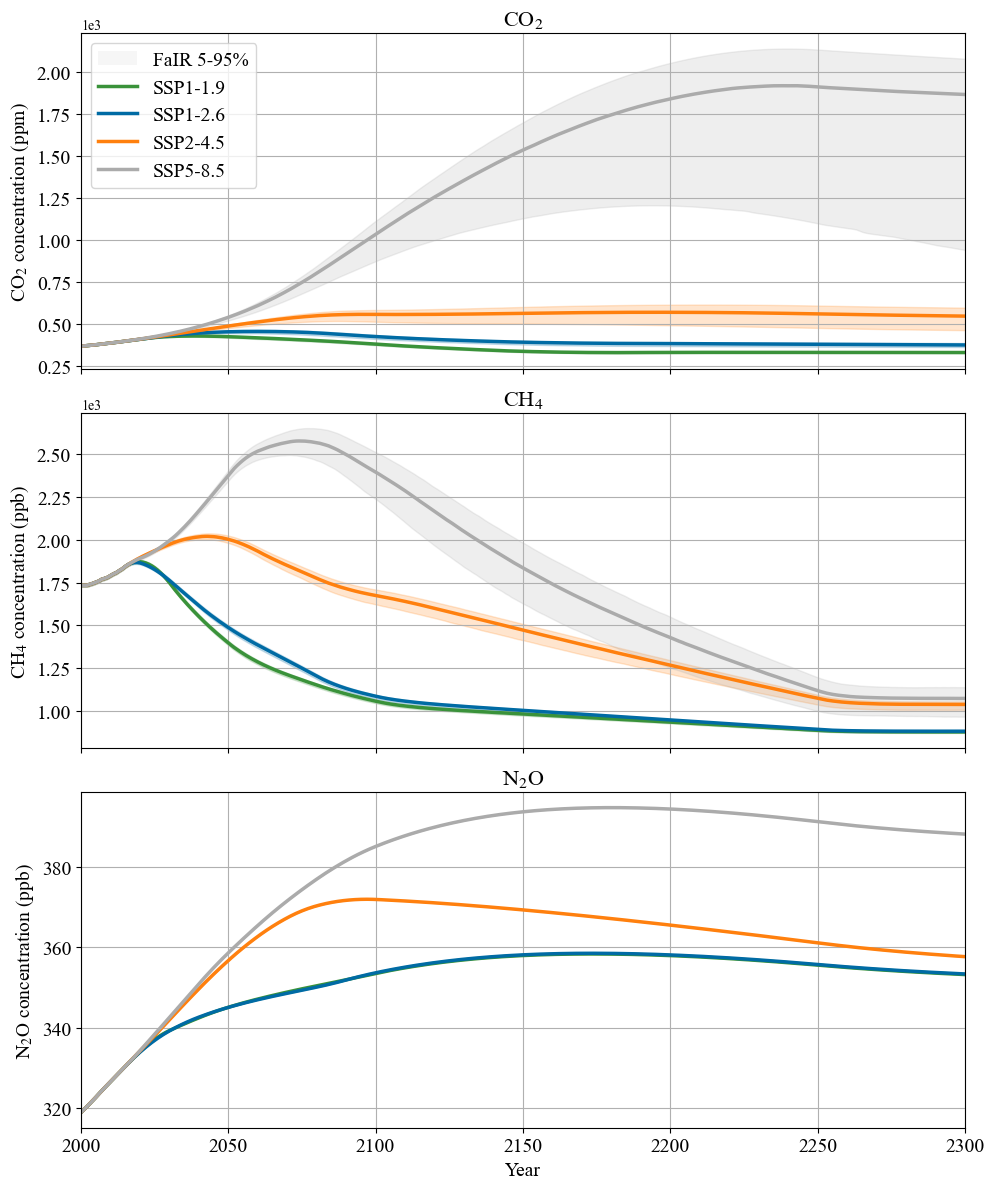

In [4]:
plot_fair_concentration_3x1_all_gases(PKL_PATH)